In [9]:
from admmviz import ADMM
from matplotlib import pyplot as plt
import numpy as np

In [10]:
admm = ADMM(alpha=1e-3, dim=64, base_dir="run_data_admm_mergesplit")

In [11]:
controll = (admm.trial(0).iters.control_cont[1])

In [17]:
(admm.trial(0).meta["rho_init"])

0.1

In [12]:
admm.tv

405.42640687119314

In [25]:
admm.control

array([0., 0., 0., ..., 0., 0., 0.])

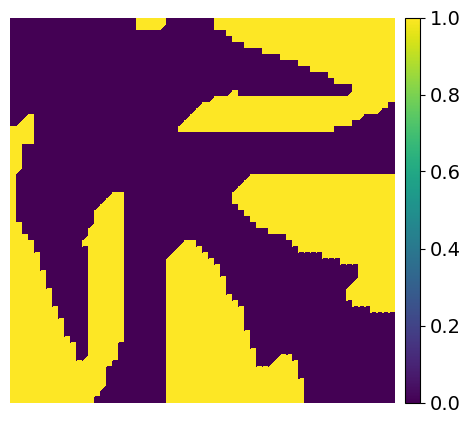

In [13]:
admm.plot_control()

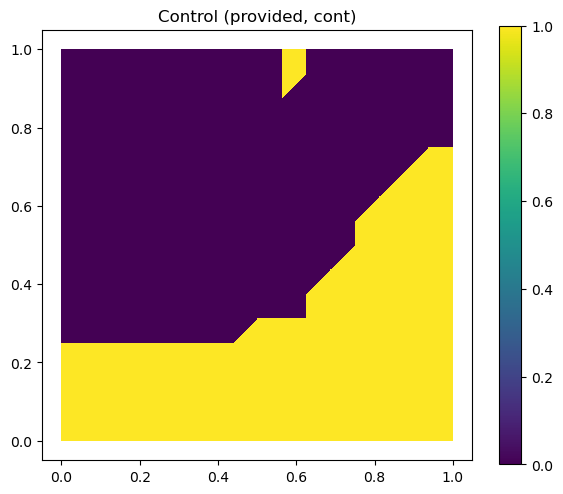

In [20]:
c = admm.trial(11).iters.control[-1]
admm.plot_control(c, cont=True)

In [22]:
import networkx as nx
import math

In [23]:
def build_graph(n_x, n_y):
        N = n_x * n_y
        graph = nx.Graph()
        graph.add_nodes_from(range(N))

        for k in range(0, N, 2):
            if k + 1 < N:
                graph.add_edge(k, k + 1)
            if (k + 2) % n_y != 0 and k + 3 < N:
                graph.add_edge(k, k + 3)
            if (k // n_y) != 0:
                nb = k - (n_y - 1)
                if nb >= 0:
                    graph.add_edge(k, nb)

        return graph

In [34]:
graph = build_graph(2,4)
(graph.edges)

EdgeView([(0, 1), (0, 3), (1, 4), (2, 3), (3, 6), (4, 5), (4, 7), (6, 7)])

In [35]:
scale = np.zeros(len(graph.edges()))
for k, (u, v) in enumerate(graph.edges()):
    scale[k] = math.sqrt(2) if abs(int(u) - int(v)) == 1 else 1.0 

In [36]:
scale

array([1.41421356, 1.        , 1.        , 1.41421356, 1.        ,
       1.41421356, 1.        , 1.41421356])

In [37]:
def _build_unitsquaremesh_right_tri(n):
        h = 1.0 / n
        nn = n + 1

        nodenrs = np.arange(nn * nn).reshape((nn, nn), order="C")

        coords = np.zeros((nn * nn, 2), dtype=float)
        for j in range(nn):
            for i in range(nn):
                coords[nodenrs[j, i]] = [i * h, j * h]

        tris = []
        tri_type = []
        bottom_edges = []
        right_edges = []

        for i in range(n):
            for j in range(n):
                bl = nodenrs[j, i]
                br = nodenrs[j, i + 1]
                tl = nodenrs[j + 1, i]
                tr = nodenrs[j + 1, i + 1]

                # default "right" diagonal: bl -> tr
                tris.append([bl, br, tr]); tri_type.append(0)
                tris.append([bl, tr, tl]); tri_type.append(1)

                if j == 0:
                    bottom_edges.append([bl, br])
                if i == n - 1:
                    right_edges.append([br, tr])

        tris = np.asarray(tris, dtype=int)
        tri_type = np.asarray(tri_type, dtype=int)
        bottom_edges = np.asarray(bottom_edges, dtype=int)
        right_edges = np.asarray(right_edges, dtype=int)

        west_nodes = nodenrs[:, 0]
        north_nodes = nodenrs[-1, :]
        dirichlet_nodes = np.unique(np.r_[west_nodes, north_nodes]).astype(int)

        return coords, tris, tri_type, bottom_edges, right_edges, dirichlet_nodes


In [38]:
coords, tris, tri_type, bottom_edges, right_edges, dirichlet_nodes = _build_unitsquaremesh_right_tri(2)

In [40]:
tris

array([[0, 1, 4],
       [0, 4, 3],
       [3, 4, 7],
       [3, 7, 6],
       [1, 2, 5],
       [1, 5, 4],
       [4, 5, 8],
       [4, 8, 7]])